In [1]:
import numpy as np
from scipy import constants
import pandas as pd
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths

# Trap Frequency and Scattering vs Tweezer Wavelength

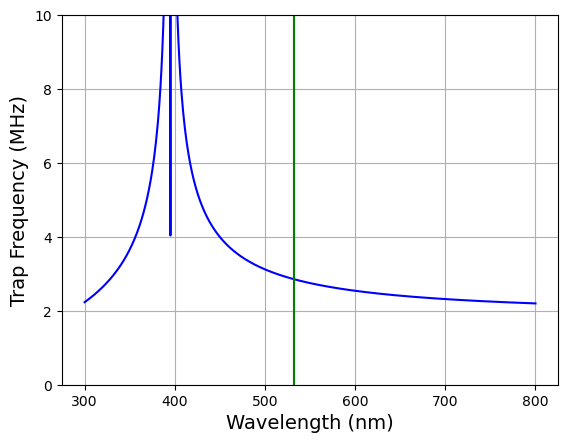

In [17]:
lams = np.linspace(300,800,500)*1e-9
omegas_twzs = 2*pi*c/lams
Popt = 500e-3
w0 = 500e-9


tweezer_pot = potential(omegas_twzs,linewidths,omega_res,Popt,w0)
w_twz_r,w_twz_a = tweezer_optical_potential_to_trap_frequency(lams,linewidths,omega_res,Popt,w0,m,tweezer_pot)
s = scattering(omegas_twzs,linewidths,omega_res,Popt,w0)

fig,ax = plt.subplots(1,1,dpi=100)

ax.plot(lams*1e9,w_twz_r*1e-6/(2*np.pi),'b')
ax.vlines(532,0,1000,'g')

#ax2=ax.twinx()
#ax2.plot(lams*1e9,s,'r')

ax.set_ylim(0,10)
#ax2.set_ylim(0,25)

ax.set_xlabel('Wavelength (nm)', fontsize=14)
ax.set_ylabel('Trap Frequency (MHz)', fontsize=14)
#ax2.set_ylabel('Scattering Rate (Hz)',color='r')

#ax.tick_params(axis='y', colors='b')
#ax2.tick_params(axis='y', colors='r')

ax.grid()
plt.show()

# Trap Frequency vs Power for Bottom Window and Side Window

In [1]:
w0_side = 1.55e-6
w0_bot = 0.2427e-6
wz_side = beam_propogation(w0_side,0,tweezer_wavelength)
wz_bot = beam_propogation(w0_bot,0,tweezer_wavelength)
P0 = np.linspace(0,1,100)

U_side = potential(omega_tweezer,linewidths,omega_res,P0,w0_side)
f_r_side = tweezer_optical_potential_to_trap_frequency(tweezer_wavelength,linewidths,omega_res,P0,w0,m,U_side)[0]

U_bot = potential(omega_tweezer,linewidths,omega_res,P0,w0_bot)
f_r_bot = tweezer_optical_potential_to_trap_frequency(tweezer_wavelength,linewidths,omega_res,P0,w0,m,U_bot)[0]

plt.plot(P0,f_r_bot,'r',label = "Bottom Window")
plt.plot(P0,f_r_side,'b',label = "Side Window")
plt.xlabel('Power (W)')
plt.ylabel('Trap Frequency (kHz)')
plt.axvline(0.05,linestyle = '--',color = 'g')
plt.axvline(1,linestyle = '--',color = 'g')
plt.legend()
plt.show()

NameError: name 'beam_propogation' is not defined